In [1]:
import numpy as np
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw

In [2]:
#function for QC-ing on a column by column basis
def basic_qc(df,varname):
    # replace bad qc values for each column with nan 
    qc_flags = [1, 2, 8]
    mask_qc = df[f'{varname}_ADJUSTED_QC'].isin(qc_flags)
    df[f'{varname}_ADJUSTED'] = df[f'{varname}_ADJUSTED'].where(mask_qc)    
    return df

In [3]:
# pdf = pd.read_csv('/Users/lilah/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv')
pdf = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv') #for stevie

/var/folders/cn/f7hyztf9023fy4lx2tlld0xh0000gn/T/ipykernel_93330/1828878927.py:2: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  pdf = pd.read_csv('/Users/steviewalker/Documents/IBIS_Project/Data/AAR_BGC_extended_region_alltime.csv') #for stevie


In [4]:
#convert to datetime, fix lat lon values with '--' (replace with nan)
pdf['DATE'] = pd.to_datetime(pdf['DATE'],format = 'mixed')
pdf['LATITUDE'] = pd.to_numeric(pdf['LATITUDE'], errors='coerce')
pdf['LONGITUDE'] = pd.to_numeric(pdf['LONGITUDE'], errors='coerce')


In [12]:
# adding year and season columns
pdf["year"] = pdf["DATE"].dt.year
pdf["month"] = pdf["DATE"].dt.month
pdf["year"] = pdf["year"].astype("Int64")
pdf["month"] = pdf["month"].astype("Int64")

df = pdf

season = (
    df["year"].astype(str) + "-" + (df["year"] + 1).astype(str)
).where(df["month"] >= 9)

season = season.where(df["month"] >= 9, 
    (df["year"] - 1).astype(str) + "-" + df["year"].astype(str)
).where(df["month"] <= 4, df["year"].astype(str))

pdf["season"] = season.astype(str)

In [13]:
pdf.dtypes

Unnamed: 0                                  int64
WMOID                                       int64
CYCLE_NUMBER                                int64
DIRECTION                                  object
DATE                               datetime64[ns]
DATE_QC                                     int64
LATITUDE                                  float64
LONGITUDE                                 float64
POSITION_QC                                 int64
PRES                                      float64
PRES_QC                                   float64
PRES_ADJUSTED                             float64
PRES_ADJUSTED_QC                          float64
PRES_ADJUSTED_ERROR                       float64
TEMP                                      float64
TEMP_QC                                   float64
TEMP_ADJUSTED                             float64
TEMP_ADJUSTED_QC                          float64
TEMP_ADJUSTED_ERROR                       float64
PSAL                                      float64


In [14]:
# define function for calculating SA, CT, MLP, potential dens, in-situ dens
def calc_phys_vars(df):
        
    # Columns needed
    cols = ['PSAL_ADJUSTED','TEMP_ADJUSTED' ,'PRES_ADJUSTED', 'LATITUDE', 'LONGITUDE']
    
    # only do calculation on good qc T and S data
    qc_flags = [1, 2, 8]
    mask_qc = df['PSAL_ADJUSTED_QC'].isin(qc_flags) & df['TEMP_ADJUSTED_QC'].isin(qc_flags)
    df['PSAL_ADJUSTED'] = df['PSAL_ADJUSTED'].where(mask_qc)
    df['TEMP_ADJUSTED'] = df['TEMP_ADJUSTED'].where(mask_qc)    
    
    # Mask valid (non-null) rows
    mask = df[cols].notnull().all(axis=1)
    
    # initialize outputs as NaN
    SA = np.full(len(df), np.nan)
    CT = np.full(len(df), np.nan)
    rho = np.full(len(df), np.nan)
    sigma0 = np.full(len(df), np.nan)
    
    # extract clean numeric arrays for valid rows
    SP = df.loc[mask, 'PSAL_ADJUSTED'].astype(float).to_numpy()
    PT = df.loc[mask, 'TEMP_ADJUSTED'].astype(float).to_numpy()
    pres = df.loc[mask, 'PRES_ADJUSTED'].astype(float).to_numpy()
    LAT = df.loc[mask, 'LATITUDE'].astype(float).to_numpy()
    LON = df.loc[mask, 'LONGITUDE'].astype(float).to_numpy()
    
    # calculate variables
    SA_valid = gsw.SA_from_SP(SP=SP, p=pres, lon=LON, lat=LAT)
    CT_valid = gsw.CT_from_t(SA=SA_valid, t=PT, p=pres)
    rho_valid = gsw.rho(SA=SA_valid, CT=CT_valid, p=pres)
    sigma0_valid = gsw.sigma0(SA=SA_valid, CT=CT_valid)
    
    # add pres to depth conversion later gsw_z_from_p(p,lat
    
    # Store back into full-length arrays
    SA[mask] = SA_valid
    CT[mask] = CT_valid
    rho[mask] = rho_valid
    sigma0[mask] = sigma0_valid
    
    # Add results to DataFrame
    df = df.copy()
    df['SA'] = SA
    df['CT'] = CT
    df['rho'] = rho
    df['sigma0'] = sigma0
    
    return df

pdf_clean = calc_phys_vars(pdf)

In [22]:
variable = 'TEMP_ADJUSTED'
title = 'testing'
xlab = 'time'
ylab= 'depth'
label_size = 12
title_size = 14
df_ts = pdf_clean
season = '2014-2015'
WMOID = 5904105

df_ts = df_ts[df_ts['season'].isin([season])]
float_data = df_ts[df_ts['WMOID'].isin([WMOID])]

time_values = pd.to_datetime(float_data['DATE']).values
pres_values = float_data['PRES'].values
param_values = float_data[variable].values
# Remove NaN values
valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
time_values = time_values[valid_indices]
pres_values = pres_values[valid_indices]
param_values = param_values[valid_indices]
# Convert time_values to float because it makes gridding data easier
time_values_num = mdates.date2num(time_values)
# Unique values for creating grids
unique_times_num = np.unique(time_values_num)
# Create a pressure axis with regular intervals, covering all existing values
intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
# Create grid for interpolation
time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
# Set param_gridded to NaN array with the same shape as the grid
param_gridded = np.full(time_grid.shape, np.nan)
# Create a DataFrame
df = pd.DataFrame({
    'time': time_values_num,
    'pressure': pres_values,
    'param': param_values
})
# Pivot the DataFrame to create a grid
param_gridded_df = df.pivot_table(
    index='pressure',
    columns='time',
    values='param',
    aggfunc='first'
)
# Create a new index that contains original and regularly spaced pressure values
all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
# Reindex the DataFrame to the combined depth axis
param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
# Perform linear interpolation to the new depth axis without extrapolation
param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
# Extract the values to the regularly spaced depth values
param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
# Assigning data to variable to graph
param_gridded = param_gridded_df.values


Text(0, 0.5, 'Pressure (dbar)')

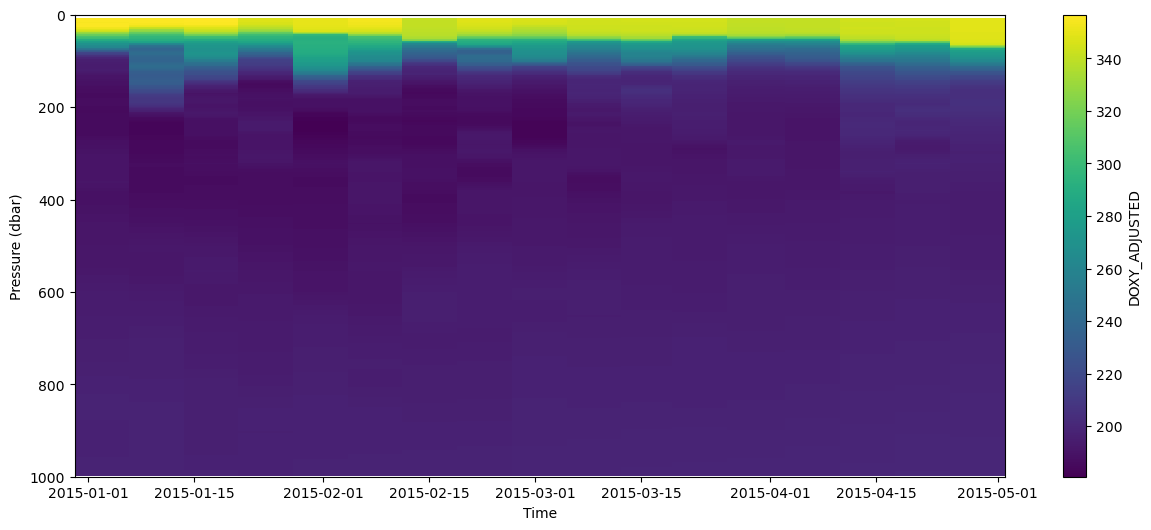

In [24]:
# these will be your inputs to the function
variable = 'DOXY_ADJUSTED'
title = 'testing'
xlab = 'time'
ylab= 'depth'
label_size = 12
title_size = 14
df_ts = pdf_clean
season = '2014-2015'
WMOID = 5904105


#subset dataframe by float and season you want to show
df_ts = df_ts[df_ts['season'].isin([season])]
float_data = df_ts[df_ts['WMOID'].isin([WMOID])]

# oneargopy regridding ----------

time_values = pd.to_datetime(float_data['DATE']).values
pres_values = float_data['PRES'].values
param_values = float_data[variable].values
# Remove NaN values
valid_indices = ~np.isnan(time_values) & ~np.isnan(pres_values) & ~np.isnan(param_values)
time_values = time_values[valid_indices]
pres_values = pres_values[valid_indices]
param_values = param_values[valid_indices]
# Convert time_values to float because it makes gridding data easier
time_values_num = mdates.date2num(time_values)
# Unique values for creating grids
unique_times_num = np.unique(time_values_num)
# Create a pressure axis with regular intervals, covering all existing values
intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
# Create grid for interpolation
time_grid, pres_grid = np.meshgrid(unique_times_num, intp_pres)
# Set param_gridded to NaN array with the same shape as the grid
param_gridded = np.full(time_grid.shape, np.nan)
# Create a DataFrame
df = pd.DataFrame({
    'time': time_values_num,
    'pressure': pres_values,
    'param': param_values
})
# Pivot the DataFrame to create a grid
param_gridded_df = df.pivot_table(
    index='pressure',
    columns='time',
    values='param',
    aggfunc='first'
)
# Create a new index that contains original and regularly spaced pressure values
all_pres = np.sort(np.unique(np.concatenate([pres_values, intp_pres])))
# Reindex the DataFrame to the combined depth axis
param_gridded_df = param_gridded_df.reindex(index=all_pres, columns=unique_times_num)
# Perform linear interpolation to the new depth axis without extrapolation
param_gridded_df.interpolate(method='linear', limit_area='inside', axis=0, inplace=True)
# Extract the values to the regularly spaced depth values
param_gridded_df = param_gridded_df.reindex(index=intp_pres, columns=unique_times_num)
# Assigning data to variable to graph
param_gridded = param_gridded_df.values

## oneargopy plotting -----------

# Plot Data
plt.figure(figsize=(15, 6))
plt.pcolormesh(time_grid, pres_grid, param_gridded, shading='auto')
# Y Axis
plt.ylim([0, 1000])
plt.gca().invert_yaxis()
# Add a colorbar to show the scale of the variable
plt.colorbar(label=variable)
# X Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
# Titles
plt.xlabel('Time')
plt.ylabel('Pressure (dbar)')
# plt.title(f'{variable} Section of Float {float_id}')

# add line to save the figure

In [18]:
intp_pres = np.arange(np.ceil(min(pres_values)), np.floor(max(pres_values)))
intp_pres.min()

8.0